### 1. 초기

In [4]:
import pandas as pd
import numpy as np

# =========================
# 1) 데이터 불러오기
# =========================
file_path = "RXRX_stock_with_indicators.csv"
df = pd.read_csv(file_path)

# 날짜 정리
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# =========================
# 2) 볼린저 밴드폭 계산
#    Bandwidth = ((Upper - Lower) / Middle) * 100
# =========================
df["BB_WIDTH"] = ((df["BB_UPPER"] - df["BB_LOWER"]) / df["BB_MID"]) * 100

# NaN 제거 대상(초기 20일 이전 등)
valid_bw = df["BB_WIDTH"].dropna()

if valid_bw.empty:
    raise ValueError("BB_WIDTH 계산 가능한 데이터가 없습니다. BB_MID/BB_UPPER/BB_LOWER 컬럼을 확인하세요.")

# =========================
# 3) 최근 값 가져오기
# =========================
latest = df.dropna(subset=["BB_WIDTH"]).iloc[-1]

latest_date = latest["Date"].date()
latest_close = latest["Close"]
latest_bw = latest["BB_WIDTH"]
latest_rsi = latest["RSI_14"] if pd.notna(latest["RSI_14"]) else np.nan

# =========================
# 4) 역사적 비교 (분위수/평균/중앙값)
# =========================
bw_mean = valid_bw.mean()
bw_median = valid_bw.median()
bw_min = valid_bw.min()
bw_max = valid_bw.max()

# 현재 밴드폭이 과거 데이터 중 몇 퍼센트 위치인지
# 예: 3.8%면 역사적으로 매우 낮은 수준
bw_percentile = (valid_bw <= latest_bw).mean() * 100

# =========================
# 5) 최근 2주/3주/4주 추세 확인
#    미국 주식 기준 대략
#    2주=10거래일, 3주=15거래일, 4주=20거래일
# =========================
lookbacks = {
    "1주(5거래일)": 5,
    "2주(10거래일)": 10,
    "3주(15거래일)": 15,
    "4주(20거래일)": 20,
}

recent_changes = {}

for label, n in lookbacks.items():
    bw_series = df["BB_WIDTH"].dropna()
    if len(bw_series) > n:
        past_value = bw_series.iloc[-(n + 1)]
        change_abs = latest_bw - past_value
        change_pct = (change_abs / past_value) * 100 if past_value != 0 else np.nan
        recent_changes[label] = {
            "past_value": past_value,
            "current_value": latest_bw,
            "change_abs": change_abs,
            "change_pct": change_pct
        }

# =========================
# 6) 최근 며칠 데이터 테이블
# =========================
recent_table = (
    df.dropna(subset=["BB_WIDTH"])
      .tail(10)[["Date", "Close", "BB_WIDTH", "RSI_14"]]
      .copy()
)
recent_table["Date"] = recent_table["Date"].dt.date
recent_table["BB_WIDTH"] = recent_table["BB_WIDTH"].round(2)
recent_table["RSI_14"] = recent_table["RSI_14"].round(2)

# =========================
# 7) squeeze 판정 로직
#    일반 예시:
#    하위 10% 이하면 강한 squeeze
#    하위 20% 이하면 squeeze 경계
# =========================
if bw_percentile <= 10:
    squeeze_status = "강한 squeeze(변동성 압축)"
elif bw_percentile <= 20:
    squeeze_status = "squeeze 경계 구간"
else:
    squeeze_status = "특별히 압축된 구간은 아님"

# =========================
# 8) 최근 밴드폭 방향성 판정
# =========================
# 최근 5거래일 기준 기울기 느낌
last_5 = df["BB_WIDTH"].dropna().tail(5).values

if len(last_5) >= 2:
    if all(np.diff(last_5) < 0):
        bw_trend = "최근 5거래일 연속 축소"
    elif all(np.diff(last_5) > 0):
        bw_trend = "최근 5거래일 연속 확대"
    elif last_5[-1] > last_5[0]:
        bw_trend = "최근 5거래일 기준 완만한 확대"
    elif last_5[-1] < last_5[0]:
        bw_trend = "최근 5거래일 기준 완만한 축소"
    else:
        bw_trend = "최근 5거래일 큰 변화 없음"
else:
    bw_trend = "최근 추세 판정 불가"

# =========================
# 9) RSI 해석
# =========================
if pd.isna(latest_rsi):
    rsi_comment = "RSI 데이터 없음"
elif latest_rsi >= 70:
    rsi_comment = "RSI 과열권"
elif latest_rsi >= 50:
    rsi_comment = "RSI 중립 이상, 상승 모멘텀 상대적으로 양호"
elif latest_rsi >= 30:
    rsi_comment = "RSI 중립 이하, 강한 상승 모멘텀은 아직 약함"
else:
    rsi_comment = "RSI 과매도권 근처"

# =========================
# 10) 해석 출력
# =========================
print("=" * 60)
print("RXRX 볼린저 밴드폭 분석")
print("=" * 60)
print(f"기준일: {latest_date}")
print(f"종가: {latest_close:.2f}")
print(f"현재 BB Width: {latest_bw:.2f}")
print(f"과거 평균 BB Width: {bw_mean:.2f}")
print(f"과거 중앙값 BB Width: {bw_median:.2f}")
print(f"과거 최저~최고: {bw_min:.2f} ~ {bw_max:.2f}")
print(f"현재 밴드폭의 역사적 분위수: 하위 {bw_percentile:.1f}%")
print(f"상태 판정: {squeeze_status}")
print(f"최근 추세: {bw_trend}")
print(f"현재 RSI(14): {latest_rsi:.2f}" if pd.notna(latest_rsi) else "현재 RSI(14): NaN")
print(f"RSI 해석: {rsi_comment}")
print()

print("[최근 기간별 밴드폭 변화]")
for label, info in recent_changes.items():
    print(
        f"- {label}: "
        f"{info['past_value']:.2f} -> {info['current_value']:.2f} "
        f"(변화 {info['change_abs']:+.2f}, {info['change_pct']:+.2f}%)"
    )

print()
print("[최근 10거래일 데이터]")
print(recent_table.to_string(index=False))

print()
print("[자동 해석]")
if bw_percentile <= 10:
    print(
        "현재 RXRX는 볼린저 밴드폭 기준 역사적으로 매우 낮은 변동성 구간에 있습니다. "
        "즉, '압축(squeeze)' 상태로 해석할 수 있습니다."
    )
elif bw_percentile <= 20:
    print(
        "현재 RXRX는 볼린저 밴드폭이 낮은 편이며, 압축 구간에 진입했을 가능성이 있습니다."
    )
else:
    print(
        "현재 RXRX는 밴드폭 기준으로 특별히 극단적인 압축 상태는 아닙니다."
    )

if "확대" in bw_trend:
    print(
        "다만 최근 밴드폭이 다시 커지기 시작했다면, 변동성 확장 국면으로 넘어가는 초기 신호일 수 있습니다."
    )
else:
    print(
        "아직 밴드폭 자체가 본격적으로 확장되지는 않아, 방향성 돌파는 확인이 더 필요합니다."
    )

if pd.notna(latest_rsi) and latest_rsi < 50:
    print(
        "RSI가 50 아래라면, 상승 모멘텀이 강하다고 보긴 어렵고 방향성은 아직 미확정 상태로 보는 편이 안전합니다."
    )

RXRX 볼린저 밴드폭 분석
기준일: 2026-03-13
종가: 3.42
현재 BB Width: 14.58
과거 평균 BB Width: 33.41
과거 중앙값 BB Width: 31.05
과거 최저~최고: 10.05 ~ 90.09
현재 밴드폭의 역사적 분위수: 하위 4.1%
상태 판정: 강한 squeeze(변동성 압축)
최근 추세: 최근 5거래일 기준 완만한 축소
현재 RSI(14): 41.26
RSI 해석: RSI 중립 이하, 강한 상승 모멘텀은 아직 약함

[최근 기간별 밴드폭 변화]
- 1주(5거래일): 18.85 -> 14.58 (변화 -4.27, -22.65%)
- 2주(10거래일): 26.71 -> 14.58 (변화 -12.13, -45.42%)
- 3주(15거래일): 41.99 -> 14.58 (변화 -27.41, -65.28%)
- 4주(20거래일): 38.51 -> 14.58 (변화 -23.93, -62.14%)

[최근 10거래일 데이터]
      Date  Close  BB_WIDTH  RSI_14
2026-03-02   3.63     24.46   42.98
2026-03-03   3.54     21.87   40.79
2026-03-04   3.64     19.17   44.20
2026-03-05   3.54     18.39   41.62
2026-03-06   3.46     18.85   39.63
2026-03-09   3.51     16.89   41.51
2026-03-10   3.44     14.48   39.65
2026-03-11   3.45     13.09   40.06
2026-03-12   3.29     14.26   35.83
2026-03-13   3.42     14.58   41.26

[자동 해석]
현재 RXRX는 볼린저 밴드폭 기준 역사적으로 매우 낮은 변동성 구간에 있습니다. 즉, '압축(squeeze)' 상태로 해석할 수 있습니다.
아직 밴드폭 자체가 본격적으로 확장되지는 않아, 방향성

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1 데이터 불러오기
# ==============================

FILE_PATH = "RXRX_stock_with_indicators.csv"

df = pd.read_csv(FILE_PATH)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# ==============================
# 2 볼린저 밴드폭 계산
# ==============================

df["BB_WIDTH"] = ((df["BB_UPPER"] - df["BB_LOWER"]) / df["BB_MID"]) * 100

# ==============================
# 3 추가 지표 계산
# ==============================

df["VOL_MA20"] = df["Volume"].rolling(20).mean()
df["VOL_RATIO_20"] = df["Volume"] / df["VOL_MA20"]

df["BW_DELTA"] = df["BB_WIDTH"].diff()

# 최근 3일 밴드폭 확장 여부
df["BW_EXPANSION_3D"] = (
    (df["BB_WIDTH"] > df["BB_WIDTH"].shift(1)) &
    (df["BB_WIDTH"].shift(1) > df["BB_WIDTH"].shift(2))
)

# ==============================
# 4 squeeze 판단
# ==============================

lookback = 120

def compute_percentile(series):
    current = series.iloc[-1]
    return (series <= current).mean() * 100

percentiles = []

for i in range(len(df)):
    if i < lookback:
        percentiles.append(np.nan)
    else:
        window = df["BB_WIDTH"].iloc[i-lookback:i]
        pct = (window <= df["BB_WIDTH"].iloc[i]).mean() * 100
        percentiles.append(pct)

df["BW_PERCENTILE_120"] = percentiles

df["SQUEEZE"] = df["BW_PERCENTILE_120"] <= 10

# ==============================
# 5 돌파 신호
# ==============================

df["UPPER_BREAK"] = df["Close"] > df["BB_UPPER"]
df["LOWER_BREAK"] = df["Close"] < df["BB_LOWER"]

# ==============================
# 6 트레이딩 시그널
# ==============================

signals = []

for i,row in df.iterrows():

    signal = "Neutral"

    if row["SQUEEZE"]:
        signal = "Squeeze watch"

    if row["UPPER_BREAK"] and row["VOL_RATIO_20"] > 1.5 and row["RSI_14"] > 50:
        signal = "Bullish breakout"

    if row["LOWER_BREAK"] and row["VOL_RATIO_20"] > 1.5 and row["RSI_14"] < 45:
        signal = "Bearish breakdown"

    if row["BW_EXPANSION_3D"] and signal == "Neutral":
        signal = "Expansion without full confirmation"

    signals.append(signal)

df["SIGNAL"] = signals

# ==============================
# 7 최근 변화 분석
# ==============================

latest = df.dropna(subset=["BB_WIDTH"]).iloc[-1]

lookbacks = {
    "1W":5,
    "2W":10,
    "3W":15,
    "4W":20
}

changes = []

for label,n in lookbacks.items():

    if len(df) > n:

        past = df["BB_WIDTH"].iloc[-n-1]
        now = latest["BB_WIDTH"]

        diff = now - past
        pct = diff/past*100

        changes.append({
            "Period":label,
            "Past_BW":past,
            "Current_BW":now,
            "Change":diff,
            "Change_%":pct
        })

changes_df = pd.DataFrame(changes)

# ==============================
# 8 Summary 생성
# ==============================

summary = pd.DataFrame({
    "Metric":[
        "Latest Date",
        "Close",
        "BB Width",
        "Bandwidth Percentile(120d)",
        "RSI",
        "Volume Ratio",
        "Current Signal"
    ],
    "Value":[
        latest["Date"],
        latest["Close"],
        latest["BB_WIDTH"],
        latest["BW_PERCENTILE_120"],
        latest["RSI_14"],
        latest["VOL_RATIO_20"],
        latest["SIGNAL"]
    ]
})

# ==============================
# 9 그래프 생성
# ==============================

# 가격 + 볼린저 밴드
plt.figure(figsize=(12,6))
plt.plot(df["Date"],df["Close"],label="Close")
plt.plot(df["Date"],df["BB_UPPER"],label="Upper")
plt.plot(df["Date"],df["BB_MID"],label="Middle")
plt.plot(df["Date"],df["BB_LOWER"],label="Lower")
plt.title("RXRX Price and Bollinger Bands")
plt.legend()
plt.savefig("rxrx_price_bbands.png")
plt.close()

# 밴드폭
plt.figure(figsize=(12,6))
plt.plot(df["Date"],df["BB_WIDTH"])
plt.title("Bollinger Bandwidth")
plt.savefig("rxrx_bandwidth.png")
plt.close()

# RSI
plt.figure(figsize=(12,6))
plt.plot(df["Date"],df["RSI_14"])
plt.axhline(70)
plt.axhline(30)
plt.title("RSI 14")
plt.savefig("rxrx_rsi.png")
plt.close()

# ==============================
# 10 CSV 저장
# ==============================

df.to_csv("RXRX_analysis_output.csv",index=False)

# ==============================
# 11 엑셀 생성
# ==============================

excel_path = "RXRX_bollinger_analysis.xlsx"

with pd.ExcelWriter(excel_path,engine="openpyxl") as writer:

    summary.to_excel(writer,sheet_name="Summary",index=False)
    changes_df.to_excel(writer,sheet_name="Recent_Changes",index=False)
    df.tail(60).to_excel(writer,sheet_name="Signal_Log",index=False)
    df.to_excel(writer,sheet_name="Analyzed_Data",index=False)

print("분석 완료")
print("엑셀 파일 생성:",excel_path)
print("그래프 파일 생성 완료")

분석 완료
엑셀 파일 생성: RXRX_bollinger_analysis.xlsx
그래프 파일 생성 완료


### 2. 개선

## Summary

,Metric,Value
0,Latest Date,2026-03-13 00:00:00
1,Close,3.42
2,BB Width,14.58
3,Bandwidth Percentile(120d),10.00
4,Squeeze Level,Squeeze
5,RSI,41.26
6,Volume Ratio,0.80
7,Upper Break,False
8,Lower Break,False
9,Current Signal,Squeeze release watch (bearish bias)


## Recent Changes

,Period,Past_BW,Current_BW,Change,Change_%
0,1W,18.85,14.58,-4.27,-22.65
1,2W,26.71,14.58,-12.13,-45.42
2,3W,41.99,14.58,-27.41,-65.28
3,4W,38.51,14.58,-23.93,-62.14


## Recent 20 Days

...

기준일은 2026-03-13 입니다.
종가는 3.42, 볼린저 밴드폭은 14.58% 입니다.
최근 120일 기준 밴드폭 백분위는 10.00% 이며, squeeze 수준은 'Squeeze' 입니다.
RSI(14)는 41.26, 거래량 비율은 0.80배 입니다.
현재 최종 신호는 'Squeeze release watch (bearish bias)' 입니다.
변동성이 압축된 상태이며, 아직 확정 돌파는 아니지만 방향성 있는 큰 움직임이 나올 가능성을 감시하는 구간입니다.
추가 확인 포인트: 상단 밴드 돌파 여부, 하단 밴드 이탈 여부, 거래량 증가 동반 여부, RSI 50 회복 여부.


## Recent 20D Interpretation

최근 20거래일 구간은 2026-02-13 ~ 2026-03-13 입니다.
종가는 3.49 에서 3.42 로 변했고, 수익률은 -2.01% 입니다.
볼린저 밴드폭은 41.20% 에서 14.58% 로 변했고, 변화율은 -64.61% 입니다.
평균 거래량 비율은 0.85배, 평균 RSI는 39.91 입니다.
이 기간 squeeze 발생 일수는 5일, 상단 돌파는 0회, 하단 이탈은 0회 입니다.
가장 자주 나온 신호는 'Neutral' 입니다.
최근 구간에서 밴드폭이 뚜렷하게 축소되어 변동성 압축이 진행된 것으로 해석됩니다.
거래량이 평균보다 낮아 아직 강한 추종 자금 유입은 제한적인 상태입니다.
RSI 평균이 약세권에 가까워 최근 흐름은 상대적으로 하방 압력이 남아 있다고 볼 수 있습니다.


## Action Guide

관찰 체크리스트
- 상방 확인: 종가가 BB_UPPER 위에서 마감하는지
- 하방 확인: 종가가 BB_LOWER 아래에서 마감하는지
- 거래량 확인: VOL_RATIO_20 이 1.5 이상인지
- 모멘텀 확인: RSI_14 가 50 이상 회복 또는 45 이하 약화되는지
- 변동성 확인: BB_WIDTH 와 BW_DELTA 가 함께 증가하는지
현재 신호는 하방 우위이므로, 추가 하락 시 밴드폭 확장 지속 여부와 거래량 재증가 여부를 확인하는 것이 중요합니다.


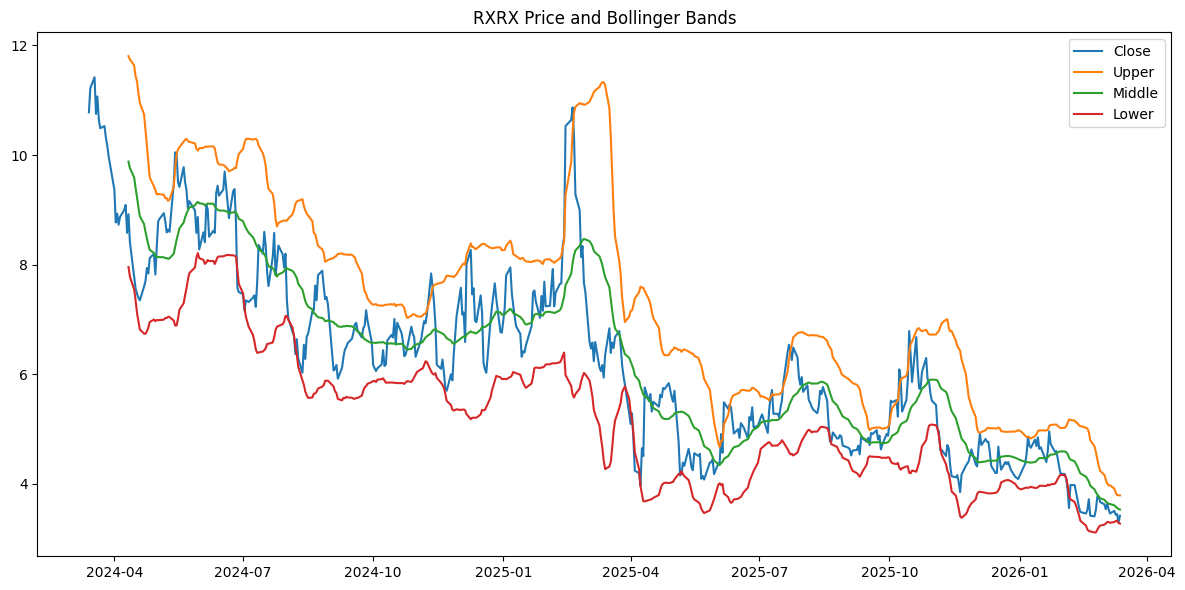

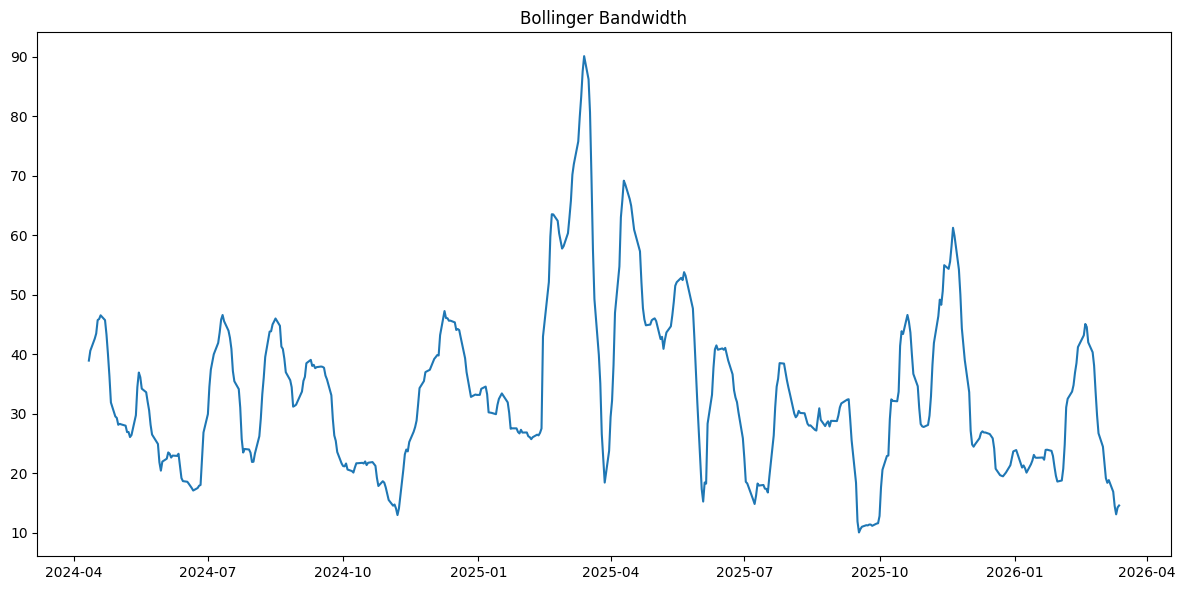

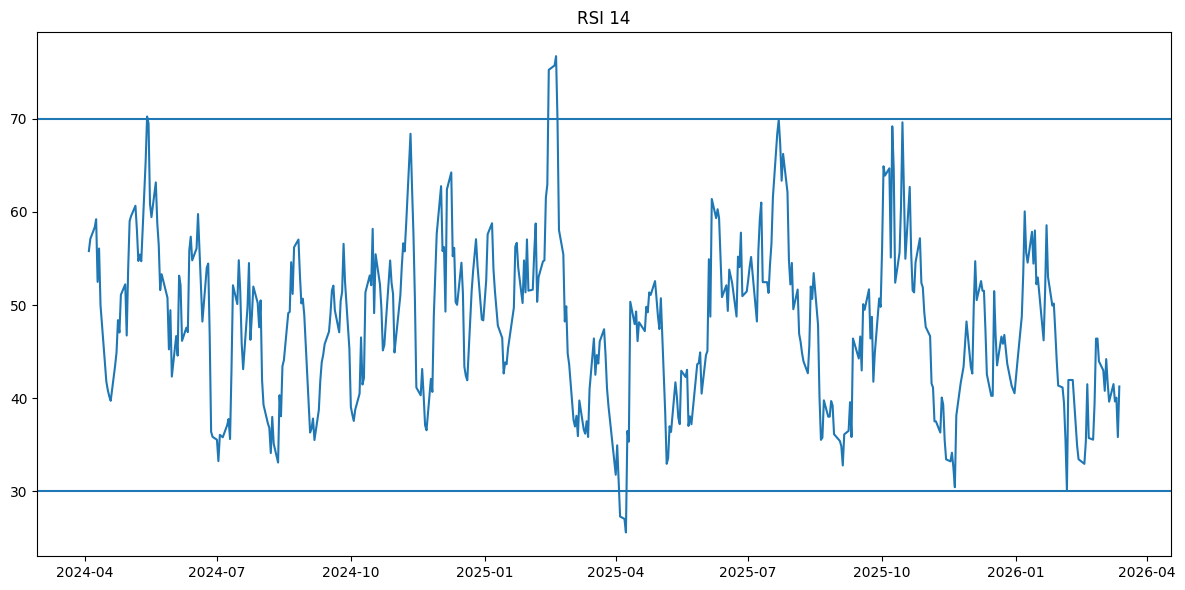

분석 완료
CSV 파일: RXRX_analysis_output.csv
엑셀 파일: RXRX_bollinger_analysis.xlsx
그래프 파일: rxrx_price_bbands.png, rxrx_bandwidth.png, rxrx_rsi.png


In [2]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

# ==============================
# 0 설정
# ==============================
FILE_PATH = "RXRX_stock_with_indicators.csv"
OUTPUT_CSV = "RXRX_analysis_output.csv"
OUTPUT_XLSX = "RXRX_bollinger_analysis.xlsx"

LOOKBACK_PERCENTILE = 120
RECENT_DAYS_FOR_LOG = 60
RECENT_DAYS_FOR_INTERPRET = 20

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# %%
# ==============================
# 1 데이터 불러오기
# ==============================
df = pd.read_csv(FILE_PATH)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

required_cols = [
    "Date", "Close", "Volume",
    "BB_UPPER", "BB_MID", "BB_LOWER",
    "RSI_14"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"필수 컬럼이 없습니다: {missing}")

# MA_20이 없으면 BB_MID 사용
if "MA_20" not in df.columns:
    df["MA_20"] = df["BB_MID"]

# %%
# ==============================
# 2 지표 계산
# ==============================
df["BB_WIDTH"] = ((df["BB_UPPER"] - df["BB_LOWER"]) / df["BB_MID"]) * 100
df["VOL_MA20"] = df["Volume"].rolling(20).mean()
df["VOL_RATIO_20"] = df["Volume"] / df["VOL_MA20"]

df["BW_DELTA"] = df["BB_WIDTH"].diff()
df["PRICE_CHANGE_PCT"] = df["Close"].pct_change() * 100

# 최근 3일 연속 밴드폭 확대
df["BW_EXPANSION_3D"] = (
    (df["BB_WIDTH"] > df["BB_WIDTH"].shift(1)) &
    (df["BB_WIDTH"].shift(1) > df["BB_WIDTH"].shift(2))
)

# 최근 3일 연속 밴드폭 축소
df["BW_CONTRACTION_3D"] = (
    (df["BB_WIDTH"] < df["BB_WIDTH"].shift(1)) &
    (df["BB_WIDTH"].shift(1) < df["BB_WIDTH"].shift(2))
)

# %%
# ==============================
# 3 squeeze 백분위 계산
# ==============================
percentiles = []

for i in range(len(df)):
    if i < LOOKBACK_PERCENTILE:
        percentiles.append(np.nan)
    else:
        window = df["BB_WIDTH"].iloc[i - LOOKBACK_PERCENTILE:i]
        current = df["BB_WIDTH"].iloc[i]
        pct = (window <= current).mean() * 100
        percentiles.append(pct)

df["BW_PERCENTILE_120"] = percentiles

# squeeze 강도 구간화
def classify_squeeze(p):
    if pd.isna(p):
        return np.nan
    if p <= 5:
        return "Ultra squeeze"
    elif p <= 10:
        return "Squeeze"
    elif p <= 20:
        return "Tight"
    else:
        return "Normal"

df["SQUEEZE_LEVEL"] = df["BW_PERCENTILE_120"].apply(classify_squeeze)
df["SQUEEZE"] = df["BW_PERCENTILE_120"] <= 10

# %%
# ==============================
# 4 돌파/이탈 및 보조조건
# ==============================
df["UPPER_BREAK"] = df["Close"] > df["BB_UPPER"]
df["LOWER_BREAK"] = df["Close"] < df["BB_LOWER"]

# 개선 포인트:
# 단순 밴드 돌파가 아니라 "변동성 확장 + 거래량 + RSI + 추세"를 함께 봄
df["BULLISH_CONFIRM"] = (
    df["UPPER_BREAK"] &
    (df["VOL_RATIO_20"] > 1.5) &
    (df["RSI_14"] > 50) &
    (df["BW_DELTA"] > 0) &
    (df["Close"] > df["MA_20"])
)

df["BEARISH_CONFIRM"] = (
    df["LOWER_BREAK"] &
    (df["VOL_RATIO_20"] > 1.5) &
    (df["RSI_14"] < 45) &
    (df["BW_DELTA"] > 0) &
    (df["Close"] < df["MA_20"])
)

# %%
# ==============================
# 5 스코어링 기반 신호 생성
# ==============================
# 기존보다 좀 더 부드럽게 상태를 읽도록 개선
def compute_signal(row):
    score_bull = 0
    score_bear = 0

    # 방향성 점수
    if row["Close"] > row["MA_20"]:
        score_bull += 1
    else:
        score_bear += 1

    if row["RSI_14"] >= 55:
        score_bull += 2
    elif row["RSI_14"] >= 50:
        score_bull += 1
    elif row["RSI_14"] <= 40:
        score_bear += 2
    elif row["RSI_14"] <= 45:
        score_bear += 1

    if row["VOL_RATIO_20"] > 1.5:
        if row["Close"] >= row["MA_20"]:
            score_bull += 1
        else:
            score_bear += 1

    if row["UPPER_BREAK"]:
        score_bull += 3
    if row["LOWER_BREAK"]:
        score_bear += 3

    if row["BW_DELTA"] > 0:
        # 밴드폭 확장은 돌파 시 더 의미가 큼
        if row["Close"] >= row["MA_20"]:
            score_bull += 1
        else:
            score_bear += 1

    # 최종 신호 규칙
    if row["BULLISH_CONFIRM"]:
        return "Bullish breakout"
    if row["BEARISH_CONFIRM"]:
        return "Bearish breakdown"

    # squeeze 중일 때
    if row["SQUEEZE"]:
        if row["BW_EXPANSION_3D"] and row["Close"] > row["MA_20"] and row["RSI_14"] >= 50:
            return "Squeeze release watch (bullish bias)"
        elif row["BW_EXPANSION_3D"] and row["Close"] < row["MA_20"] and row["RSI_14"] < 50:
            return "Squeeze release watch (bearish bias)"
        else:
            return "Squeeze watch"

    # squeeze는 아니지만 확장 중
    if row["BW_EXPANSION_3D"]:
        if score_bull >= score_bear + 2:
            return "Expansion with bullish bias"
        elif score_bear >= score_bull + 2:
            return "Expansion with bearish bias"
        else:
            return "Expansion without full confirmation"

    return "Neutral"

df["SIGNAL"] = df.apply(compute_signal, axis=1)

# %%
# ==============================
# 6 최근 변화 분석
# ==============================
latest = df.dropna(subset=["BB_WIDTH"]).iloc[-1]

lookbacks = {
    "1W": 5,
    "2W": 10,
    "3W": 15,
    "4W": 20
}

changes = []

for label, n in lookbacks.items():
    if len(df) > n:
        past = df["BB_WIDTH"].iloc[-n-1]
        now = latest["BB_WIDTH"]

        diff = now - past
        pct = (diff / past * 100) if past != 0 else np.nan

        changes.append({
            "Period": label,
            "Past_BW": past,
            "Current_BW": now,
            "Change": diff,
            "Change_%": pct
        })

changes_df = pd.DataFrame(changes)

# %%
# ==============================
# 7 해석 문장 생성 함수
# ==============================
def safe_fmt(x, digits=2):
    if pd.isna(x):
        return "N/A"
    return f"{x:.{digits}f}"

def interpret_latest(row):
    lines = []

    lines.append(f"기준일은 {row['Date'].date()} 입니다.")
    lines.append(f"종가는 {safe_fmt(row['Close'])}, 볼린저 밴드폭은 {safe_fmt(row['BB_WIDTH'])}% 입니다.")
    lines.append(f"최근 120일 기준 밴드폭 백분위는 {safe_fmt(row['BW_PERCENTILE_120'])}% 이며, squeeze 수준은 '{row['SQUEEZE_LEVEL']}' 입니다.")
    lines.append(f"RSI(14)는 {safe_fmt(row['RSI_14'])}, 거래량 비율은 {safe_fmt(row['VOL_RATIO_20'])}배 입니다.")
    lines.append(f"현재 최종 신호는 '{row['SIGNAL']}' 입니다.")

    # 상태 해석
    if row["SIGNAL"] == "Bullish breakout":
        lines.append("상단 밴드 돌파가 거래량 증가, RSI 우위, 밴드폭 확장과 함께 확인되어 상승 돌파 신호로 해석됩니다.")
    elif row["SIGNAL"] == "Bearish breakdown":
        lines.append("하단 밴드 이탈이 거래량 증가, RSI 약세, 밴드폭 확장과 함께 확인되어 하락 이탈 신호로 해석됩니다.")
    elif "Squeeze" in str(row["SIGNAL"]):
        lines.append("변동성이 압축된 상태이며, 아직 확정 돌파는 아니지만 방향성 있는 큰 움직임이 나올 가능성을 감시하는 구간입니다.")
    elif "Expansion" in str(row["SIGNAL"]):
        lines.append("밴드폭이 최근 확대되고 있어 변동성이 살아나는 단계로 해석되지만, 아직 완전한 돌파 확인은 부족합니다.")
    else:
        lines.append("현재는 뚜렷한 방향성 확정 신호가 부족한 중립 구간으로 해석됩니다.")

    # 관찰 포인트
    watch = []
    if row["Close"] <= row["BB_UPPER"]:
        watch.append("상단 밴드 돌파 여부")
    if row["Close"] >= row["BB_LOWER"]:
        watch.append("하단 밴드 이탈 여부")
    if row["VOL_RATIO_20"] <= 1.5:
        watch.append("거래량 증가 동반 여부")
    if row["RSI_14"] < 50:
        watch.append("RSI 50 회복 여부")
    if row["BW_DELTA"] <= 0:
        watch.append("밴드폭 재확대 여부")

    if watch:
        lines.append("추가 확인 포인트: " + ", ".join(watch) + ".")

    return "\n".join(lines)

def interpret_recent_20d(df, n=20):
    recent = df.dropna(subset=["BB_WIDTH"]).tail(n).copy()

    if len(recent) < 5:
        return "최근 구간 해석을 하기에는 데이터가 부족합니다."

    start = recent.iloc[0]
    end = recent.iloc[-1]

    bw_start = start["BB_WIDTH"]
    bw_end = end["BB_WIDTH"]
    bw_change = bw_end - bw_start
    bw_change_pct = (bw_change / bw_start * 100) if bw_start != 0 else np.nan

    price_start = start["Close"]
    price_end = end["Close"]
    price_change_pct = ((price_end - price_start) / price_start * 100) if price_start != 0 else np.nan

    avg_vol_ratio = recent["VOL_RATIO_20"].mean()
    avg_rsi = recent["RSI_14"].mean()

    squeeze_days = int(recent["SQUEEZE"].fillna(False).sum())
    upper_breaks = int(recent["UPPER_BREAK"].fillna(False).sum())
    lower_breaks = int(recent["LOWER_BREAK"].fillna(False).sum())

    signals_count = recent["SIGNAL"].value_counts().to_dict()

    dominant_signal = recent["SIGNAL"].mode().iloc[0] if not recent["SIGNAL"].mode().empty else "N/A"

    lines = []
    lines.append(f"최근 {len(recent)}거래일 구간은 {start['Date'].date()} ~ {end['Date'].date()} 입니다.")
    lines.append(f"종가는 {safe_fmt(price_start)} 에서 {safe_fmt(price_end)} 로 변했고, 수익률은 {safe_fmt(price_change_pct)}% 입니다.")
    lines.append(f"볼린저 밴드폭은 {safe_fmt(bw_start)}% 에서 {safe_fmt(bw_end)}% 로 변했고, 변화율은 {safe_fmt(bw_change_pct)}% 입니다.")
    lines.append(f"평균 거래량 비율은 {safe_fmt(avg_vol_ratio)}배, 평균 RSI는 {safe_fmt(avg_rsi)} 입니다.")
    lines.append(f"이 기간 squeeze 발생 일수는 {squeeze_days}일, 상단 돌파는 {upper_breaks}회, 하단 이탈은 {lower_breaks}회 입니다.")
    lines.append(f"가장 자주 나온 신호는 '{dominant_signal}' 입니다.")

    # 해석 로직
    if bw_change_pct <= -20:
        lines.append("최근 구간에서 밴드폭이 뚜렷하게 축소되어 변동성 압축이 진행된 것으로 해석됩니다.")
    elif bw_change_pct >= 20:
        lines.append("최근 구간에서 밴드폭이 확대되어 변동성이 살아나는 과정으로 해석됩니다.")
    else:
        lines.append("최근 구간의 밴드폭 변화는 제한적이며, 변동성 방향성이 아직 강하지 않습니다.")

    if squeeze_days >= n * 0.3:
        lines.append("최근 구간의 상당 부분이 squeeze 상태였기 때문에, 에너지가 축적되는 박스권 또는 방향 대기 국면으로 볼 수 있습니다.")

    if avg_vol_ratio < 1.0:
        lines.append("거래량이 평균보다 낮아 아직 강한 추종 자금 유입은 제한적인 상태입니다.")
    else:
        lines.append("거래량이 평균 수준 이상으로 유지되어 움직임의 신뢰도가 높아질 가능성이 있습니다.")

    if avg_rsi >= 55:
        lines.append("RSI 평균이 강세권에 가까워 최근 흐름은 상대적으로 상방 우위로 해석됩니다.")
    elif avg_rsi <= 45:
        lines.append("RSI 평균이 약세권에 가까워 최근 흐름은 상대적으로 하방 압력이 남아 있다고 볼 수 있습니다.")
    else:
        lines.append("RSI 평균이 중립권에 있어 방향성 확정은 아직 부족합니다.")

    return "\n".join(lines)

def make_action_guide(row):
    guides = []

    guides.append("관찰 체크리스트")
    guides.append("- 상방 확인: 종가가 BB_UPPER 위에서 마감하는지")
    guides.append("- 하방 확인: 종가가 BB_LOWER 아래에서 마감하는지")
    guides.append("- 거래량 확인: VOL_RATIO_20 이 1.5 이상인지")
    guides.append("- 모멘텀 확인: RSI_14 가 50 이상 회복 또는 45 이하 약화되는지")
    guides.append("- 변동성 확인: BB_WIDTH 와 BW_DELTA 가 함께 증가하는지")

    if row["SIGNAL"] == "Squeeze watch":
        guides.append("현재는 스퀴즈 감시 구간이므로, 성급한 방향 확정보다 돌파와 거래량 동반 여부를 우선 확인하는 것이 좋습니다.")
    elif "bullish" in str(row["SIGNAL"]).lower():
        guides.append("현재 신호는 상방 우위이므로, 다음 며칠간 거래량 유지와 밴드 상단 안착 여부를 체크하는 것이 중요합니다.")
    elif "bearish" in str(row["SIGNAL"]).lower():
        guides.append("현재 신호는 하방 우위이므로, 추가 하락 시 밴드폭 확장 지속 여부와 거래량 재증가 여부를 확인하는 것이 중요합니다.")
    else:
        guides.append("현재는 중립 또는 초기 확장 국면이므로, 돌파 확정 전까지는 신호 과대해석을 피하는 것이 좋습니다.")

    return "\n".join(guides)

# %%
# ==============================
# 8 요약표 생성
# ==============================
summary = pd.DataFrame({
    "Metric": [
        "Latest Date",
        "Close",
        "BB Width",
        "Bandwidth Percentile(120d)",
        "Squeeze Level",
        "RSI",
        "Volume Ratio",
        "Upper Break",
        "Lower Break",
        "Current Signal"
    ],
    "Value": [
        latest["Date"],
        latest["Close"],
        latest["BB_WIDTH"],
        latest["BW_PERCENTILE_120"],
        latest["SQUEEZE_LEVEL"],
        latest["RSI_14"],
        latest["VOL_RATIO_20"],
        latest["UPPER_BREAK"],
        latest["LOWER_BREAK"],
        latest["SIGNAL"]
    ]
})

latest_interpretation = interpret_latest(latest)
recent_20d_interpretation = interpret_recent_20d(df, n=RECENT_DAYS_FOR_INTERPRET)
action_guide = make_action_guide(latest)

text_report = pd.DataFrame({
    "Section": [
        "Latest Interpretation",
        "Recent 20D Interpretation",
        "Action Guide"
    ],
    "Text": [
        latest_interpretation,
        recent_20d_interpretation,
        action_guide
    ]
})

# %%
# ==============================
# 9 노트북 셀 출력
# ==============================
display(Markdown("## Summary"))
display(summary)

display(Markdown("## Recent Changes"))
display(changes_df)

display(Markdown(f"## Recent {RECENT_DAYS_FOR_INTERPRET} Days"))
recent_view_cols = [
    "Date", "Close", "BB_WIDTH", "BW_PERCENTILE_120", "SQUEEZE_LEVEL",
    "RSI_14", "VOL_RATIO_20", "UPPER_BREAK", "LOWER_BREAK",
    "BW_EXPANSION_3D", "SIGNAL"
]
display(df.tail(RECENT_DAYS_FOR_INTERPRET)[recent_view_cols])

display(Markdown("## Latest Interpretation"))
print(latest_interpretation)

display(Markdown("## Recent 20D Interpretation"))
print(recent_20d_interpretation)

display(Markdown("## Action Guide"))
print(action_guide)

# %%
# ==============================
# 10 그래프 생성
# ==============================
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["BB_UPPER"], label="Upper")
plt.plot(df["Date"], df["BB_MID"], label="Middle")
plt.plot(df["Date"], df["BB_LOWER"], label="Lower")
plt.title("RXRX Price and Bollinger Bands")
plt.legend()
plt.tight_layout()
plt.savefig("rxrx_price_bbands.png", dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["BB_WIDTH"])
plt.title("Bollinger Bandwidth")
plt.tight_layout()
plt.savefig("rxrx_bandwidth.png", dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["RSI_14"])
plt.axhline(70)
plt.axhline(30)
plt.title("RSI 14")
plt.tight_layout()
plt.savefig("rxrx_rsi.png", dpi=150)
plt.show()
plt.close()

# %%
# ==============================
# 11 결과 저장
# ==============================
df.to_csv(OUTPUT_CSV, index=False)

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    summary.to_excel(writer, sheet_name="Summary", index=False)
    changes_df.to_excel(writer, sheet_name="Recent_Changes", index=False)
    df.tail(RECENT_DAYS_FOR_LOG).to_excel(writer, sheet_name="Signal_Log", index=False)
    df.to_excel(writer, sheet_name="Analyzed_Data", index=False)
    text_report.to_excel(writer, sheet_name="Interpretation", index=False)

print("분석 완료")
print("CSV 파일:", OUTPUT_CSV)
print("엑셀 파일:", OUTPUT_XLSX)
print("그래프 파일: rxrx_price_bbands.png, rxrx_bandwidth.png, rxrx_rsi.png")

## Summary

,Metric,Value
0,Latest Date,2026-03-13 00:00:00
1,Close,12.51
2,BB Width,19.87
3,BW Percentile(120d),57.50
4,Squeeze Level,Normal
5,RSI_14,45.46
6,Volume Ratio(20),0.68
7,BULL_SCORE,1
8,BEAR_SCORE,1
9,SCORE_DIFF,0


## Recent Changes

,Period,Past_BW,Current_BW,Change,Change_%
0,1W,26.29,19.87,-6.42,-24.43
1,2W,32.19,19.87,-12.33,-38.29
2,3W,44.09,19.87,-24.22,-54.94
3,4W,48.06,19.87,-28.20,-58.67


## Recent 20 Days Snapshot

...

최근 이벤트 로그 기준으로 마지막 30개 이벤트를 검토했습니다.
'Squeeze' 는 14회 발생했습니다.
'Squeeze release' 는 4회 발생했습니다.
'Bearish breakdown candidate' 는 4회 발생했습니다.
'Bullish breakout candidate' 는 3회 발생했습니다.
'Failed bullish breakout' 는 3회 발생했습니다.
'Failed bearish breakdown' 는 1회 발생했습니다.
'Bearish breakdown confirmed' 는 1회 발생했습니다.
확정된 하락 이탈 이벤트가 존재하므로, 약세 추세 전개 가능성을 더 신중히 볼 필요가 있습니다.
실패한 돌파 이벤트가 있었다면 최근 구간에 허위 신호가 존재했음을 의미하므로, 후속 거래량과 유지력을 더 중시해야 합니다.
squeeze 또는 release 이벤트가 반복되면, 큰 방향성 움직임 직전의 압축-해제 패턴일 가능성을 고려할 수 있습니다.


## Action Guide

상방 확인 기준: 종가가 BB_UPPER 위에서 마감하고, 거래량 비율이 1.5 이상이며, RSI가 50 이상 유지되는지 확인합니다.
하방 확인 기준: 종가가 BB_LOWER 아래에서 마감하고, 거래량 비율이 1.5 이상이며, RSI가 45 이하로 약화되는지 확인합니다.
진짜 돌파 여부는 당일 신호보다 다음날 follow-through 유지 여부를 더 중요하게 봅니다.
밴드폭이 다시 커지면서 가격이 밴드 바깥 또는 중심선 위아래에서 안착하는지 확인하는 것이 중요합니다.
현재는 중립 또는 편향 단계이므로, 단독 지표보다 가격, 거래량, 밴드폭의 동시 확인이 중요합니다.


## Risk Checklist

거래량이 평균 이하라 신호 신뢰도가 낮을 수 있습니다.
밴드폭이 재확대되지 않으면 방향성 신호가 약할 수 있습니다.
RSI가 중립권이라 방향성이 애매할 수 있습니다.


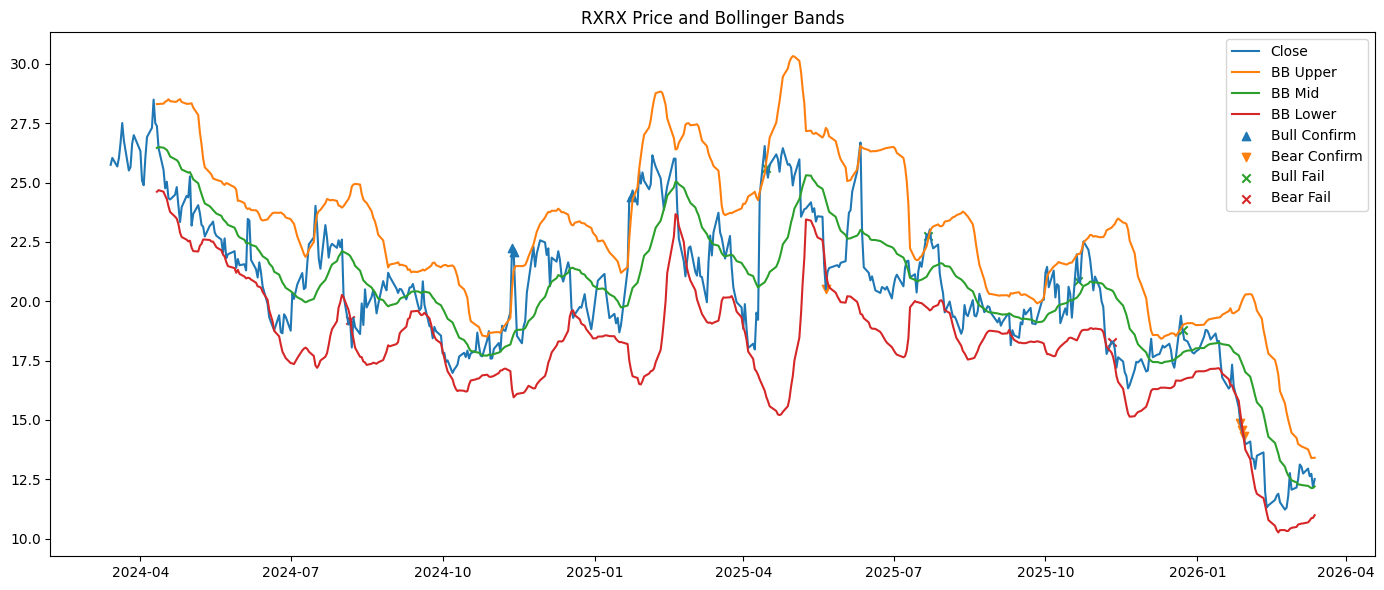

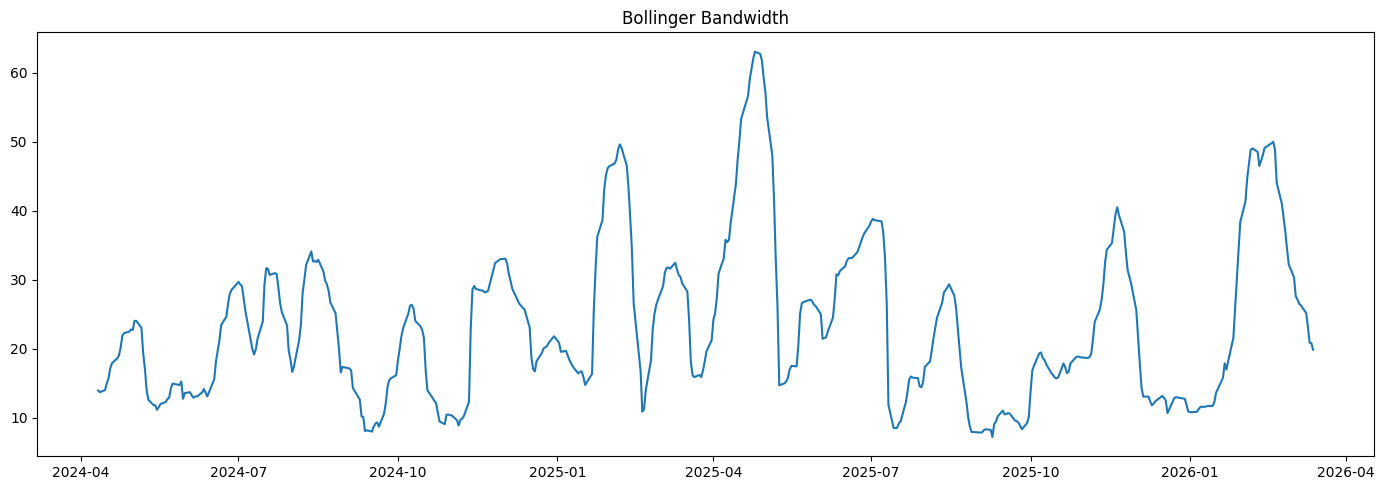

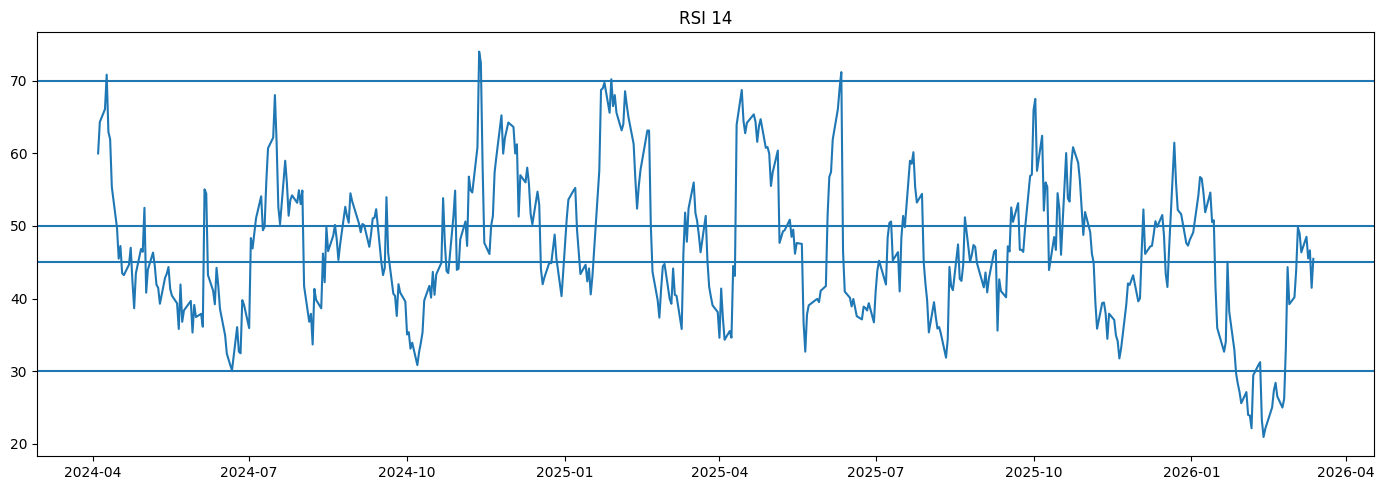

분석 완료
CSV 저장: SDGR_analysis_output.csv
엑셀 저장: SDGR_bollinger_analysis.xlsx
차트 저장: sdgr_price_bbands.png, sdgr_bandwidth.png, sdgr_rsi.png


In [4]:
# %%
# ==========================================
# RXRX Bollinger Analysis - Final Notebook Version
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from pathlib import Path

# ------------------------------------------
# 0) 사용자 설정
# ------------------------------------------
FILE_PATH = "SDGR_stock_with_indicators.csv"

OUTPUT_DIR = Path(".")
OUTPUT_CSV = OUTPUT_DIR / "SDGR_analysis_output.csv"
OUTPUT_XLSX = OUTPUT_DIR / "SDGR_bollinger_analysis.xlsx"

PRICE_BBANDS_PNG = OUTPUT_DIR / "sdgr_price_bbands.png"
BANDWIDTH_PNG = OUTPUT_DIR / "sdgr_bandwidth.png"
RSI_PNG = OUTPUT_DIR / "sdgr_rsi.png"

LOOKBACK_PERCENTILE = 120
RECENT_DAYS_FOR_LOG = 60
RECENT_DAYS_FOR_INTERPRET = 20
RECENT_EVENT_DAYS = 30

VOL_RATIO_BREAKOUT = 1.50
VOL_RATIO_FOLLOW = 1.10
RSI_BULL = 50
RSI_BEAR = 45
PRICE_MOVE_MIN_PCT = 2.0  # breakout / breakdown candle strength
SQUEEZE_THRESHOLD = 10    # percentile <= 10
TIGHT_THRESHOLD = 20      # percentile <= 20

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# %%
# ------------------------------------------
# 1) 유틸 함수
# ------------------------------------------
def safe_fmt(x, digits=2):
    if pd.isna(x):
        return "N/A"
    return f"{x:.{digits}f}"

def safe_pct_change(start, end):
    if pd.isna(start) or pd.isna(end) or start == 0:
        return np.nan
    return (end - start) / start * 100

def bool_to_text(x):
    if pd.isna(x):
        return "N/A"
    return "Yes" if bool(x) else "No"

def section(title):
    display(Markdown(f"## {title}"))

def subsection(title):
    display(Markdown(f"### {title}"))

def classify_squeeze(percentile):
    if pd.isna(percentile):
        return np.nan
    if percentile <= 5:
        return "Ultra squeeze"
    elif percentile <= 10:
        return "Squeeze"
    elif percentile <= 20:
        return "Tight"
    else:
        return "Normal"

def classify_signal_strength(score_diff_abs):
    if pd.isna(score_diff_abs):
        return "Unknown"
    if score_diff_abs >= 5:
        return "Strong"
    elif score_diff_abs >= 3:
        return "Moderate"
    elif score_diff_abs >= 1:
        return "Weak"
    return "Flat"

def make_bullet_lines(lines):
    return "\n".join([f"- {line}" for line in lines if str(line).strip()])

# %%
# ------------------------------------------
# 2) 데이터 불러오기 및 검증
# ------------------------------------------
df = pd.read_csv(FILE_PATH)

required_cols = [
    "Date", "Close", "Volume",
    "BB_UPPER", "BB_MID", "BB_LOWER",
    "RSI_14"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"필수 컬럼이 없습니다: {missing}")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# MA_20이 없는 경우 BB_MID를 사용
if "MA_20" not in df.columns:
    df["MA_20"] = df["BB_MID"]

# 있으면 같이 활용
for ma_col in ["MA_5", "MA_20", "MA_60", "MA_120", "MA_240"]:
    if ma_col not in df.columns:
        df[ma_col] = np.nan

# %%
# ------------------------------------------
# 3) 핵심 지표 계산
# ------------------------------------------
df["BB_WIDTH"] = ((df["BB_UPPER"] - df["BB_LOWER"]) / df["BB_MID"]) * 100
df["VOL_MA20"] = df["Volume"].rolling(20).mean()
df["VOL_RATIO_20"] = df["Volume"] / df["VOL_MA20"]

df["PRICE_CHANGE_PCT"] = df["Close"].pct_change() * 100
df["BW_DELTA"] = df["BB_WIDTH"].diff()
df["BW_DELTA_PCT"] = df["BB_WIDTH"].pct_change() * 100

df["RET_3D_PCT"] = df["Close"].pct_change(3) * 100
df["RET_5D_PCT"] = df["Close"].pct_change(5) * 100

df["ABOVE_MA20"] = df["Close"] > df["MA_20"]
df["ABOVE_MA60"] = df["Close"] > df["MA_60"]

df["RSI_REGIME"] = np.select(
    [
        df["RSI_14"] >= 60,
        df["RSI_14"] >= 50,
        df["RSI_14"] <= 40,
        df["RSI_14"] <= 45,
    ],
    [
        "Bullish",
        "Bullish-neutral",
        "Bearish",
        "Bearish-neutral",
    ],
    default="Neutral"
)

# 최근 3일 연속 밴드폭 확대/축소
df["BW_EXPANSION_3D"] = (
    (df["BB_WIDTH"] > df["BB_WIDTH"].shift(1)) &
    (df["BB_WIDTH"].shift(1) > df["BB_WIDTH"].shift(2))
)

df["BW_CONTRACTION_3D"] = (
    (df["BB_WIDTH"] < df["BB_WIDTH"].shift(1)) &
    (df["BB_WIDTH"].shift(1) < df["BB_WIDTH"].shift(2))
)

# %%
# ------------------------------------------
# 4) 120일 밴드폭 percentile 계산
# ------------------------------------------
percentiles = []
for i in range(len(df)):
    if i < LOOKBACK_PERCENTILE:
        percentiles.append(np.nan)
    else:
        window = df["BB_WIDTH"].iloc[i - LOOKBACK_PERCENTILE:i]
        current = df["BB_WIDTH"].iloc[i]
        pct = (window <= current).mean() * 100
        percentiles.append(pct)

df["BW_PERCENTILE_120"] = percentiles
df["SQUEEZE_LEVEL"] = df["BW_PERCENTILE_120"].apply(classify_squeeze)
df["SQUEEZE"] = df["BW_PERCENTILE_120"] <= SQUEEZE_THRESHOLD
df["TIGHT"] = df["BW_PERCENTILE_120"] <= TIGHT_THRESHOLD

# %%
# ------------------------------------------
# 5) 밴드 돌파 / 이탈 / 후보 신호
# ------------------------------------------
df["UPPER_BREAK"] = df["Close"] > df["BB_UPPER"]
df["LOWER_BREAK"] = df["Close"] < df["BB_LOWER"]

# breakout / breakdown "캔들 강도" 필터
df["STRONG_UP_DAY"] = df["PRICE_CHANGE_PCT"] >= PRICE_MOVE_MIN_PCT
df["STRONG_DOWN_DAY"] = df["PRICE_CHANGE_PCT"] <= -PRICE_MOVE_MIN_PCT

# 후보 신호
df["BULLISH_CANDIDATE"] = (
    df["UPPER_BREAK"] &
    (df["VOL_RATIO_20"] >= VOL_RATIO_BREAKOUT) &
    (df["RSI_14"] >= RSI_BULL) &
    (df["BW_DELTA"] > 0) &
    (df["Close"] > df["MA_20"]) &
    (df["STRONG_UP_DAY"])
)

df["BEARISH_CANDIDATE"] = (
    df["LOWER_BREAK"] &
    (df["VOL_RATIO_20"] >= VOL_RATIO_BREAKOUT) &
    (df["RSI_14"] <= RSI_BEAR) &
    (df["BW_DELTA"] > 0) &
    (df["Close"] < df["MA_20"]) &
    (df["STRONG_DOWN_DAY"])
)

# %%
# ------------------------------------------
# 6) 스코어링
# ------------------------------------------
bull_scores = []
bear_scores = []

for _, row in df.iterrows():
    bull = 0
    bear = 0

    # 추세
    if pd.notna(row["MA_20"]):
        if row["Close"] > row["MA_20"]:
            bull += 1
        else:
            bear += 1

    if pd.notna(row["MA_60"]):
        if row["Close"] > row["MA_60"]:
            bull += 1
        else:
            bear += 1

    # RSI
    if row["RSI_14"] >= 60:
        bull += 2
    elif row["RSI_14"] >= 50:
        bull += 1
    elif row["RSI_14"] <= 40:
        bear += 2
    elif row["RSI_14"] <= 45:
        bear += 1

    # 거래량
    if row["VOL_RATIO_20"] >= 1.8:
        if row["Close"] >= row["MA_20"]:
            bull += 2
        else:
            bear += 2
    elif row["VOL_RATIO_20"] >= 1.2:
        if row["Close"] >= row["MA_20"]:
            bull += 1
        else:
            bear += 1

    # 밴드 돌파
    if row["UPPER_BREAK"]:
        bull += 3
    if row["LOWER_BREAK"]:
        bear += 3

    # 밴드폭 확장
    if row["BW_DELTA"] > 0:
        if row["Close"] >= row["MA_20"]:
            bull += 1
        else:
            bear += 1

    # 단기 수익률
    if pd.notna(row["RET_3D_PCT"]):
        if row["RET_3D_PCT"] >= 4:
            bull += 1
        elif row["RET_3D_PCT"] <= -4:
            bear += 1

    bull_scores.append(bull)
    bear_scores.append(bear)

df["BULL_SCORE"] = bull_scores
df["BEAR_SCORE"] = bear_scores
df["SCORE_DIFF"] = df["BULL_SCORE"] - df["BEAR_SCORE"]
df["SIGNAL_STRENGTH"] = df["SCORE_DIFF"].abs().apply(classify_signal_strength)

# %%
# ------------------------------------------
# 7) 기본 신호 판정
# ------------------------------------------
def compute_base_signal(row):
    # 확정 후보 우선
    if row["BULLISH_CANDIDATE"]:
        return "Bullish breakout candidate"
    if row["BEARISH_CANDIDATE"]:
        return "Bearish breakdown candidate"

    # squeeze / release
    if row["SQUEEZE"]:
        if row["BW_EXPANSION_3D"]:
            if row["SCORE_DIFF"] >= 2:
                return "Squeeze release watch (bullish bias)"
            elif row["SCORE_DIFF"] <= -2:
                return "Squeeze release watch (bearish bias)"
            else:
                return "Squeeze release watch"
        return "Squeeze watch"

    # tight but not squeeze
    if row["TIGHT"]:
        if row["SCORE_DIFF"] >= 2:
            return "Tight range with bullish bias"
        elif row["SCORE_DIFF"] <= -2:
            return "Tight range with bearish bias"
        else:
            return "Tight range"

    # expansion
    if row["BW_EXPANSION_3D"]:
        if row["SCORE_DIFF"] >= 3:
            return "Expansion with bullish bias"
        elif row["SCORE_DIFF"] <= -3:
            return "Expansion with bearish bias"
        return "Expansion without full confirmation"

    # 평상시
    if row["SCORE_DIFF"] >= 3:
        return "Bullish trend bias"
    elif row["SCORE_DIFF"] <= -3:
        return "Bearish trend bias"
    return "Neutral"

df["BASE_SIGNAL"] = df.apply(compute_base_signal, axis=1)

# %%
# ------------------------------------------
# 8) Follow-through 확인 로직
# ------------------------------------------
# 아이디어:
# 오늘 breakout candidate가 나왔으면
# 다음날에도 가격 유지 / 거래량 / RSI / 상단 밴드 인근 유지 여부를 체크하여
# confirmed / failed 로 재분류

df["FOLLOW_BULL"] = False
df["FOLLOW_BEAR"] = False
df["FAILED_BULL"] = False
df["FAILED_BEAR"] = False

for i in range(len(df) - 1):
    today = df.iloc[i]
    nxt = df.iloc[i + 1]

    # Bullish follow-through
    if today["BULLISH_CANDIDATE"]:
        bull_follow = (
            (nxt["Close"] >= today["Close"] * 0.985) and   # 다음날 급반락 회피
            (nxt["Close"] >= nxt["MA_20"]) and
            (nxt["RSI_14"] >= 50) and
            ((nxt["UPPER_BREAK"]) or (nxt["Close"] >= nxt["BB_MID"])) and
            (nxt["VOL_RATIO_20"] >= VOL_RATIO_FOLLOW or nxt["PRICE_CHANGE_PCT"] >= 0)
        )
        if bull_follow:
            df.loc[df.index[i + 1], "FOLLOW_BULL"] = True
        else:
            df.loc[df.index[i + 1], "FAILED_BULL"] = True

    # Bearish follow-through
    if today["BEARISH_CANDIDATE"]:
        bear_follow = (
            (nxt["Close"] <= today["Close"] * 1.015) and   # 다음날 급반등 회피
            (nxt["Close"] <= nxt["MA_20"]) and
            (nxt["RSI_14"] <= 45) and
            ((nxt["LOWER_BREAK"]) or (nxt["Close"] <= nxt["BB_MID"])) and
            (nxt["VOL_RATIO_20"] >= VOL_RATIO_FOLLOW or nxt["PRICE_CHANGE_PCT"] <= 0)
        )
        if bear_follow:
            df.loc[df.index[i + 1], "FOLLOW_BEAR"] = True
        else:
            df.loc[df.index[i + 1], "FAILED_BEAR"] = True

# 최종 신호 재정의
def compute_final_signal(row):
    if row["FOLLOW_BULL"]:
        return "Bullish breakout confirmed"
    if row["FOLLOW_BEAR"]:
        return "Bearish breakdown confirmed"
    if row["FAILED_BULL"]:
        return "Failed bullish breakout"
    if row["FAILED_BEAR"]:
        return "Failed bearish breakdown"
    return row["BASE_SIGNAL"]

df["SIGNAL"] = df["BASE_SIGNAL"].copy()
mask_follow = df["FOLLOW_BULL"] | df["FOLLOW_BEAR"] | df["FAILED_BULL"] | df["FAILED_BEAR"]
df.loc[mask_follow, "SIGNAL"] = df.loc[mask_follow].apply(compute_final_signal, axis=1)

# %%
# ------------------------------------------
# 9) 이벤트 로그 생성
# ------------------------------------------
event_rows = []

for i, row in df.iterrows():
    event_type = None
    details = []

    if row["BULLISH_CANDIDATE"]:
        event_type = "Bullish breakout candidate"
        details.append("상단 밴드 돌파")
        details.append("거래량 증가")
        details.append("RSI 강세")
        details.append("밴드폭 확대")
    elif row["BEARISH_CANDIDATE"]:
        event_type = "Bearish breakdown candidate"
        details.append("하단 밴드 이탈")
        details.append("거래량 증가")
        details.append("RSI 약세")
        details.append("밴드폭 확대")
    elif row["FOLLOW_BULL"]:
        event_type = "Bullish breakout confirmed"
        details.append("다음날 follow-through 확인")
    elif row["FOLLOW_BEAR"]:
        event_type = "Bearish breakdown confirmed"
        details.append("다음날 follow-through 확인")
    elif row["FAILED_BULL"]:
        event_type = "Failed bullish breakout"
        details.append("후속 상승 유지 실패")
    elif row["FAILED_BEAR"]:
        event_type = "Failed bearish breakdown"
        details.append("후속 하락 유지 실패")
    elif row["SQUEEZE"] and row["BW_EXPANSION_3D"]:
        event_type = "Squeeze release"
        details.append("squeeze 이후 밴드폭 확대")
    elif row["SQUEEZE"]:
        event_type = "Squeeze"
        details.append("변동성 압축")

    if event_type is not None:
        event_rows.append({
            "Date": row["Date"],
            "Event_Type": event_type,
            "Close": row["Close"],
            "BB_WIDTH": row["BB_WIDTH"],
            "BW_PERCENTILE_120": row["BW_PERCENTILE_120"],
            "RSI_14": row["RSI_14"],
            "VOL_RATIO_20": row["VOL_RATIO_20"],
            "Signal": row["SIGNAL"],
            "Details": ", ".join(details)
        })

events_df = pd.DataFrame(event_rows)

# %%
# ------------------------------------------
# 10) 최근 변화 분석
# ------------------------------------------
latest = df.dropna(subset=["BB_WIDTH"]).iloc[-1]

lookbacks = {
    "1W": 5,
    "2W": 10,
    "3W": 15,
    "4W": 20
}

changes = []
for label, n in lookbacks.items():
    if len(df) > n:
        past = df["BB_WIDTH"].iloc[-n - 1]
        now = latest["BB_WIDTH"]
        diff = now - past
        pct = diff / past * 100 if past != 0 else np.nan

        changes.append({
            "Period": label,
            "Past_BW": past,
            "Current_BW": now,
            "Change": diff,
            "Change_%": pct
        })

changes_df = pd.DataFrame(changes)

# %%
# ------------------------------------------
# 11) 해석 함수
# ------------------------------------------
def interpret_latest(row):
    lines = []

    lines.append(f"기준일은 {row['Date'].date()} 입니다.")
    lines.append(f"종가는 {safe_fmt(row['Close'])}, 볼린저 밴드폭은 {safe_fmt(row['BB_WIDTH'])}% 입니다.")
    lines.append(f"최근 120거래일 기준 밴드폭 percentile은 {safe_fmt(row['BW_PERCENTILE_120'])}% 이고, squeeze 수준은 '{row['SQUEEZE_LEVEL']}' 입니다.")
    lines.append(f"RSI(14)는 {safe_fmt(row['RSI_14'])}, 거래량 비율은 {safe_fmt(row['VOL_RATIO_20'])}배 입니다.")
    lines.append(f"bull score는 {safe_fmt(row['BULL_SCORE'], 0)}, bear score는 {safe_fmt(row['BEAR_SCORE'], 0)}, score diff는 {safe_fmt(row['SCORE_DIFF'], 0)} 입니다.")
    lines.append(f"현재 최종 신호는 '{row['SIGNAL']}' 이며 강도는 '{row['SIGNAL_STRENGTH']}' 입니다.")

    # 상태 해석
    signal = str(row["SIGNAL"])

    if signal == "Bullish breakout confirmed":
        lines.append("상단 밴드 돌파 이후 다음날 follow-through가 확인되어, 단순 일시적 급등보다 지속성 있는 상승 돌파로 해석할 수 있습니다.")
    elif signal == "Bearish breakdown confirmed":
        lines.append("하단 밴드 이탈 이후 다음날 follow-through가 확인되어, 단순 흔들림보다 지속성 있는 하락 이탈로 해석할 수 있습니다.")
    elif signal == "Bullish breakout candidate":
        lines.append("상승 돌파 후보가 발생했지만, 아직 다음날 follow-through가 확인되지 않았으므로 확정 신호보다는 후보 신호로 보는 것이 적절합니다.")
    elif signal == "Bearish breakdown candidate":
        lines.append("하락 이탈 후보가 발생했지만, 아직 다음날 follow-through가 확인되지 않았으므로 확정 신호보다는 후보 신호로 보는 것이 적절합니다.")
    elif signal == "Failed bullish breakout":
        lines.append("직전 상방 돌파 시도가 있었으나 다음날 유지에 실패하여 가짜 돌파일 가능성이 높아졌습니다.")
    elif signal == "Failed bearish breakdown":
        lines.append("직전 하방 이탈 시도가 있었으나 다음날 유지에 실패하여 가짜 하락 이탈 가능성이 높아졌습니다.")
    elif "Squeeze" in signal:
        lines.append("현재는 변동성 압축 구간 또는 압축 해제 직전 구간으로, 방향성이 정해지기 전 에너지가 축적되는 단계로 해석됩니다.")
    elif "Expansion" in signal:
        lines.append("밴드폭이 확대되고 있어 변동성이 살아나는 중이며, 아직 확정 돌파는 아니지만 추세 전개 초기일 가능성을 살펴볼 필요가 있습니다.")
    elif "Bullish trend bias" in signal:
        lines.append("추세 및 모멘텀 점수상 상방 우위가 관찰되지만, 명확한 밴드 돌파 확정은 부족한 상태입니다.")
    elif "Bearish trend bias" in signal:
        lines.append("추세 및 모멘텀 점수상 하방 우위가 관찰되지만, 명확한 밴드 이탈 확정은 부족한 상태입니다.")
    else:
        lines.append("현재는 뚜렷한 방향성 확정 신호가 부족한 중립 상태로 해석됩니다.")

    watch = []
    if row["Close"] <= row["BB_UPPER"]:
        watch.append("상단 밴드 종가 돌파 여부")
    if row["Close"] >= row["BB_LOWER"]:
        watch.append("하단 밴드 종가 이탈 여부")
    if row["VOL_RATIO_20"] < VOL_RATIO_BREAKOUT:
        watch.append("거래량 증가 동반 여부")
    if row["RSI_14"] < 50 and row["SCORE_DIFF"] >= 0:
        watch.append("RSI 50 회복 여부")
    if row["RSI_14"] > 45 and row["SCORE_DIFF"] < 0:
        watch.append("RSI 45 하향 여부")
    if row["BW_DELTA"] <= 0:
        watch.append("밴드폭 재확대 여부")
    if row["SIGNAL"] in ["Bullish breakout candidate", "Bearish breakdown candidate"]:
        watch.append("다음날 follow-through 확인")

    if watch:
        lines.append("추가 확인 포인트는 " + ", ".join(watch) + " 입니다.")

    return "\n".join(lines)

def interpret_recent_period(data, n=20):
    recent = data.dropna(subset=["BB_WIDTH"]).tail(n).copy()
    if len(recent) < 5:
        return "최근 구간 해석을 하기에는 데이터가 부족합니다."

    start = recent.iloc[0]
    end = recent.iloc[-1]

    price_start = start["Close"]
    price_end = end["Close"]
    price_change_pct = safe_pct_change(price_start, price_end)

    bw_start = start["BB_WIDTH"]
    bw_end = end["BB_WIDTH"]
    bw_change_pct = safe_pct_change(bw_start, bw_end)

    avg_vol_ratio = recent["VOL_RATIO_20"].mean()
    avg_rsi = recent["RSI_14"].mean()
    squeeze_days = int(recent["SQUEEZE"].fillna(False).sum())
    tight_days = int(recent["TIGHT"].fillna(False).sum())
    upper_breaks = int(recent["UPPER_BREAK"].fillna(False).sum())
    lower_breaks = int(recent["LOWER_BREAK"].fillna(False).sum())

    dominant_signal = recent["SIGNAL"].mode().iloc[0] if not recent["SIGNAL"].mode().empty else "N/A"
    max_close = recent["Close"].max()
    min_close = recent["Close"].min()
    range_pct = safe_pct_change(min_close, max_close)

    lines = []
    lines.append(f"최근 {len(recent)}거래일 구간은 {start['Date'].date()} 부터 {end['Date'].date()} 까지입니다.")
    lines.append(f"종가는 {safe_fmt(price_start)} 에서 {safe_fmt(price_end)} 로 변했고, 누적 변화율은 {safe_fmt(price_change_pct)}% 입니다.")
    lines.append(f"같은 기간 볼린저 밴드폭은 {safe_fmt(bw_start)}% 에서 {safe_fmt(bw_end)}% 로 변했고, 변화율은 {safe_fmt(bw_change_pct)}% 입니다.")
    lines.append(f"구간 내 가격 범위는 {safe_fmt(min_close)} ~ {safe_fmt(max_close)} 이며, 고저 범위는 약 {safe_fmt(range_pct)}% 입니다.")
    lines.append(f"평균 거래량 비율은 {safe_fmt(avg_vol_ratio)}배, 평균 RSI는 {safe_fmt(avg_rsi)} 입니다.")
    lines.append(f"squeeze 일수는 {squeeze_days}일, tight 구간 일수는 {tight_days}일, 상단 돌파는 {upper_breaks}회, 하단 이탈은 {lower_breaks}회 입니다.")
    lines.append(f"가장 자주 등장한 최종 신호는 '{dominant_signal}' 입니다.")

    if pd.notna(bw_change_pct):
        if bw_change_pct <= -20:
            lines.append("최근 구간에서 밴드폭이 뚜렷하게 축소되어 변동성 압축이 진행된 것으로 해석됩니다.")
        elif bw_change_pct >= 20:
            lines.append("최근 구간에서 밴드폭이 확대되어 변동성이 살아나는 과정으로 해석됩니다.")
        else:
            lines.append("최근 구간의 밴드폭 변화는 제한적이며, 변동성 방향성은 아직 강하게 확정되지 않았습니다.")

    if squeeze_days >= max(3, int(n * 0.3)):
        lines.append("구간의 상당 부분이 squeeze 상태였으므로 에너지 축적 또는 박스권 압축 구간일 가능성이 높습니다.")

    if avg_vol_ratio < 1.0:
        lines.append("평균 거래량이 평시보다 낮아 강한 추종 자금 유입은 아직 제한적인 상태입니다.")
    elif avg_vol_ratio >= 1.2:
        lines.append("평균 거래량이 평시 대비 높은 편이어서 움직임의 신뢰도를 높일 수 있습니다.")
    else:
        lines.append("거래량은 대체로 평균 부근이며, 거래량만으로 강한 방향성을 확정하기는 어렵습니다.")

    if avg_rsi >= 55:
        lines.append("평균 RSI가 강세권에 가까워 상방 우위가 상대적으로 더 강합니다.")
    elif avg_rsi <= 45:
        lines.append("평균 RSI가 약세권에 가까워 하방 압력이 아직 남아 있다고 볼 수 있습니다.")
    else:
        lines.append("평균 RSI는 중립권에 가까워 방향성 확정은 아직 부족합니다.")

    return "\n".join(lines)

def interpret_events(events_df, n=30):
    if events_df.empty:
        return "최근 이벤트가 없습니다."

    recent_events = events_df.tail(n).copy()
    counts = recent_events["Event_Type"].value_counts().to_dict()

    lines = []
    lines.append(f"최근 이벤트 로그 기준으로 마지막 {len(recent_events)}개 이벤트를 검토했습니다.")
    for event_type, cnt in counts.items():
        lines.append(f"'{event_type}' 는 {cnt}회 발생했습니다.")

    if "Bullish breakout confirmed" in counts:
        lines.append("확정된 상승 돌파 이벤트가 존재하므로, 단순 감시 단계를 넘어 실제 추세 전개가 있었는지 추가 확인이 필요합니다.")
    if "Bearish breakdown confirmed" in counts:
        lines.append("확정된 하락 이탈 이벤트가 존재하므로, 약세 추세 전개 가능성을 더 신중히 볼 필요가 있습니다.")
    if "Failed bullish breakout" in counts or "Failed bearish breakdown" in counts:
        lines.append("실패한 돌파 이벤트가 있었다면 최근 구간에 허위 신호가 존재했음을 의미하므로, 후속 거래량과 유지력을 더 중시해야 합니다.")
    if "Squeeze" in counts or "Squeeze release" in counts:
        lines.append("squeeze 또는 release 이벤트가 반복되면, 큰 방향성 움직임 직전의 압축-해제 패턴일 가능성을 고려할 수 있습니다.")

    return "\n".join(lines)

def make_action_guide(row):
    lines = []
    lines.append("상방 확인 기준: 종가가 BB_UPPER 위에서 마감하고, 거래량 비율이 1.5 이상이며, RSI가 50 이상 유지되는지 확인합니다.")
    lines.append("하방 확인 기준: 종가가 BB_LOWER 아래에서 마감하고, 거래량 비율이 1.5 이상이며, RSI가 45 이하로 약화되는지 확인합니다.")
    lines.append("진짜 돌파 여부는 당일 신호보다 다음날 follow-through 유지 여부를 더 중요하게 봅니다.")
    lines.append("밴드폭이 다시 커지면서 가격이 밴드 바깥 또는 중심선 위아래에서 안착하는지 확인하는 것이 중요합니다.")

    sig = str(row["SIGNAL"])
    if sig == "Squeeze watch":
        lines.append("현재는 스퀴즈 감시 단계이므로, 성급한 방향 추정보다 돌파와 거래량 동반 여부를 기다리는 접근이 적절합니다.")
    elif "candidate" in sig.lower():
        lines.append("현재는 후보 신호 단계이므로, 다음 거래일의 유지력 확인 전까지는 확정 신호처럼 과대해석하지 않는 것이 좋습니다.")
    elif "confirmed" in sig.lower():
        lines.append("현재는 확인된 신호 단계이므로, 추세 지속성과 거래량 유지 여부를 중심으로 관리하는 것이 좋습니다.")
    elif "failed" in sig.lower():
        lines.append("직전 돌파 시도가 실패한 상태이므로, 반대 방향 재전개 가능성까지 열어 두고 보수적으로 해석하는 편이 좋습니다.")
    else:
        lines.append("현재는 중립 또는 편향 단계이므로, 단독 지표보다 가격, 거래량, 밴드폭의 동시 확인이 중요합니다.")

    return "\n".join(lines)

def make_risk_checklist(row):
    risks = []

    if row["VOL_RATIO_20"] < 1.0:
        risks.append("거래량이 평균 이하라 신호 신뢰도가 낮을 수 있습니다.")
    if row["BW_DELTA"] <= 0:
        risks.append("밴드폭이 재확대되지 않으면 방향성 신호가 약할 수 있습니다.")
    if 45 <= row["RSI_14"] <= 55:
        risks.append("RSI가 중립권이라 방향성이 애매할 수 있습니다.")
    if row["SIGNAL"] in ["Bullish breakout candidate", "Bearish breakdown candidate"]:
        risks.append("다음날 follow-through 미확인 상태라 가짜 돌파일 수 있습니다.")
    if row["SIGNAL"] in ["Failed bullish breakout", "Failed bearish breakdown"]:
        risks.append("최근 실패 신호가 발생해 변동성 함정 구간일 수 있습니다.")
    if row["SQUEEZE"] and not row["BW_EXPANSION_3D"]:
        risks.append("스퀴즈는 확인되지만 아직 release가 시작되지 않았습니다.")

    if not risks:
        risks.append("현재 특별히 두드러진 리스크는 제한적이지만, 단일 지표 의존은 피하는 것이 좋습니다.")

    return "\n".join(risks)

# %%
# ------------------------------------------
# 12) 요약 테이블 및 텍스트 리포트
# ------------------------------------------
summary = pd.DataFrame({
    "Metric": [
        "Latest Date",
        "Close",
        "BB Width",
        "BW Percentile(120d)",
        "Squeeze Level",
        "RSI_14",
        "Volume Ratio(20)",
        "BULL_SCORE",
        "BEAR_SCORE",
        "SCORE_DIFF",
        "Signal Strength",
        "UPPER_BREAK",
        "LOWER_BREAK",
        "Current Signal"
    ],
    "Value": [
        latest["Date"],
        latest["Close"],
        latest["BB_WIDTH"],
        latest["BW_PERCENTILE_120"],
        latest["SQUEEZE_LEVEL"],
        latest["RSI_14"],
        latest["VOL_RATIO_20"],
        latest["BULL_SCORE"],
        latest["BEAR_SCORE"],
        latest["SCORE_DIFF"],
        latest["SIGNAL_STRENGTH"],
        latest["UPPER_BREAK"],
        latest["LOWER_BREAK"],
        latest["SIGNAL"]
    ]
})

latest_interpretation = interpret_latest(latest)
recent_20d_interpretation = interpret_recent_period(df, n=RECENT_DAYS_FOR_INTERPRET)
events_interpretation = interpret_events(events_df, n=RECENT_EVENT_DAYS)
action_guide = make_action_guide(latest)
risk_checklist = make_risk_checklist(latest)

text_report = pd.DataFrame({
    "Section": [
        "Latest Interpretation",
        "Recent 20D Interpretation",
        "Recent Events Interpretation",
        "Action Guide",
        "Risk Checklist"
    ],
    "Text": [
        latest_interpretation,
        recent_20d_interpretation,
        events_interpretation,
        action_guide,
        risk_checklist
    ]
})

# %%
# ------------------------------------------
# 13) 노트북 셀 출력
# ------------------------------------------
section("Summary")
display(summary)

section("Recent Changes")
display(changes_df)

section(f"Recent {RECENT_DAYS_FOR_INTERPRET} Days Snapshot")
recent_view_cols = [
    "Date", "Close", "PRICE_CHANGE_PCT", "BB_WIDTH", "BW_DELTA",
    "BW_PERCENTILE_120", "SQUEEZE_LEVEL", "RSI_14", "VOL_RATIO_20",
    "BULL_SCORE", "BEAR_SCORE", "SCORE_DIFF",
    "UPPER_BREAK", "LOWER_BREAK", "BULLISH_CANDIDATE", "BEARISH_CANDIDATE",
    "FOLLOW_BULL", "FOLLOW_BEAR", "FAILED_BULL", "FAILED_BEAR",
    "SIGNAL"
]
display(df.tail(RECENT_DAYS_FOR_INTERPRET)[recent_view_cols])

section(f"Recent Events (last {RECENT_EVENT_DAYS} rows)")
if not events_df.empty:
    display(events_df.tail(RECENT_EVENT_DAYS))
else:
    print("최근 이벤트가 없습니다.")

section("Latest Interpretation")
print(latest_interpretation)

section("Recent 20D Interpretation")
print(recent_20d_interpretation)

section("Recent Events Interpretation")
print(events_interpretation)

section("Action Guide")
print(action_guide)

section("Risk Checklist")
print(risk_checklist)

# %%
# ------------------------------------------
# 14) 시각화
# ------------------------------------------
# 14-1 가격 + 볼린저 밴드
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["BB_UPPER"], label="BB Upper")
plt.plot(df["Date"], df["BB_MID"], label="BB Mid")
plt.plot(df["Date"], df["BB_LOWER"], label="BB Lower")

# 최근 confirmed / failed 이벤트 마커
bull_conf = df[df["FOLLOW_BULL"]]
bear_conf = df[df["FOLLOW_BEAR"]]
bull_fail = df[df["FAILED_BULL"]]
bear_fail = df[df["FAILED_BEAR"]]

if not bull_conf.empty:
    plt.scatter(bull_conf["Date"], bull_conf["Close"], marker="^", label="Bull Confirm")
if not bear_conf.empty:
    plt.scatter(bear_conf["Date"], bear_conf["Close"], marker="v", label="Bear Confirm")
if not bull_fail.empty:
    plt.scatter(bull_fail["Date"], bull_fail["Close"], marker="x", label="Bull Fail")
if not bear_fail.empty:
    plt.scatter(bear_fail["Date"], bear_fail["Close"], marker="x", label="Bear Fail")

plt.title("RXRX Price and Bollinger Bands")
plt.legend()
plt.tight_layout()
plt.savefig(PRICE_BBANDS_PNG, dpi=150)
plt.show()
plt.close()

# 14-2 밴드폭
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["BB_WIDTH"], label="BB Width")
plt.title("Bollinger Bandwidth")
plt.tight_layout()
plt.savefig(BANDWIDTH_PNG, dpi=150)
plt.show()
plt.close()

# 14-3 RSI
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["RSI_14"], label="RSI(14)")
plt.axhline(70)
plt.axhline(50)
plt.axhline(45)
plt.axhline(30)
plt.title("RSI 14")
plt.tight_layout()
plt.savefig(RSI_PNG, dpi=150)
plt.show()
plt.close()

# %%
# ------------------------------------------
# 15) 결과 저장
# ------------------------------------------
df.to_csv(OUTPUT_CSV, index=False)

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    summary.to_excel(writer, sheet_name="Summary", index=False)
    changes_df.to_excel(writer, sheet_name="Recent_Changes", index=False)
    df.tail(RECENT_DAYS_FOR_LOG).to_excel(writer, sheet_name="Signal_Log", index=False)
    events_df.to_excel(writer, sheet_name="Events", index=False)
    text_report.to_excel(writer, sheet_name="Interpretation", index=False)
    df.to_excel(writer, sheet_name="Analyzed_Data", index=False)

print("분석 완료")
print(f"CSV 저장: {OUTPUT_CSV}")
print(f"엑셀 저장: {OUTPUT_XLSX}")
print(f"차트 저장: {PRICE_BBANDS_PNG}, {BANDWIDTH_PNG}, {RSI_PNG}")